Import Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

Softmax Function

In [13]:
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

Test Softmax

In [14]:
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)

row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"

print("Softmax function passed!")

Softmax function passed!


Prediction Function

In [15]:
def predict_softmax(X, W, b):
    z = np.dot(X, W) + b
    probs = softmax(z)
    predicted_classes = np.argmax(probs, axis=1)
    return predicted_classes

Test Prediction

In [16]:
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

y_pred_test = predict_softmax(X_test, W_test, b_test)

assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Prediction passed:", y_pred_test)

Prediction passed: [1 1 0]


Loss Function

In [17]:
def loss_softmax(y_pred, y):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.sum(y * np.log(y_pred)) / y.shape[0]
    return loss

Test Loss

In [18]:
y_true = np.array([[1,0,0],[0,1,0],[0,0,1]])

y_pred_correct = np.array([
    [0.9,0.05,0.05],
    [0.1,0.85,0.05],
    [0.05,0.1,0.85]
])

y_pred_wrong = np.array([
    [0.05,0.05,0.9],
    [0.1,0.05,0.85],
    [0.85,0.1,0.05]
])

loss1 = loss_softmax(y_pred_correct, y_true)
loss2 = loss_softmax(y_pred_wrong, y_true)

assert loss1 < loss2, "Loss test failed"
print("Loss function passed")

Loss function passed


Cost Function

In [19]:
def cost_softmax(X, y, W, b):
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    total_loss = -np.sum(y * np.log(y_pred))
    return total_loss / n

Gradient Function

In [20]:
def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

Gradient Test

In [21]:
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1,0,0],[0,1,0],[0,0,1]])

W_test = np.array([[0.4,0.2,0.1],[0.3,0.7,0.5]])
b_test = np.array([0.1,0.2,0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

z = np.dot(X_test, W_test) + b_test
y_pred = softmax(z)

grad_W_manual = np.dot(X_test.T, (y_pred - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual)
assert np.allclose(grad_b, grad_b_manual)

print("Gradient test passed")

Gradient test passed


Gradient Descent

In [22]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W
        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")

    return W, b, cost_history

Load Dataset

In [23]:
def load_and_prepare_mnist(csv_file):
    df = pd.read_csv(csv_file)

    y = df.iloc[:,0].values
    X = df.iloc[:,1:].values

    X = X / 255.0

    return train_test_split(X, y, test_size=0.2, random_state=42)

Load Data

In [25]:
X_train, X_test, y_train, y_test = load_and_prepare_mnist("/content/mnist_dataset.csv")

One Hot Encoding

In [26]:
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1,1))
y_test = encoder.transform(y_test.reshape(-1,1))

Initialize

In [30]:
d = X_train.shape[1]
c = y_train.shape[1]

W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

alpha = 0.1
n_iter = 500

Train

In [31]:
W, b, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter, show_cost=True)

Iteration 0, Cost: 2.2091671297320485
Iteration 100, Cost: 0.6066997762840082
Iteration 200, Cost: 0.48893276850176537
Iteration 300, Cost: 0.4404271560356707
Iteration 400, Cost: 0.41243480949884564


Plot Cost

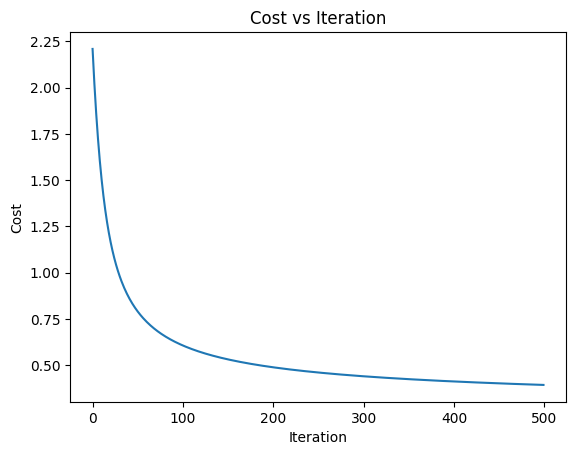

In [32]:
plt.plot(cost_history)
plt.title("Cost vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

Evaluation

In [ ]:
y_pred = predict_softmax(X_test, W, b)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Qsn1:
Is extracting pixel values sufficient for effective feature extraction? Why or why not?

-> Extracting pixel values alone is not sufficient because it only represents raw intensity values and does not capture important features like edges, shapes, and patterns. However, it can still work for simple models like softmax regression, but may not perform well for complex tasks.

Qsn2:
Provide an interpretation of the output based on your understanding.

->
The model performs well for linearly separable data because it can create a straight decision boundary to separate the classes. However, for non-linearly separable data, the model performs poorly since it cannot form complex boundaries, leading to misclassification.

Qsn3: Describe any challenges you faced while implementing the code above.

->
Some challenges included understanding the softmax function, handling matrix dimension mismatches, debugging errors in the implementation, and interpreting the results such as decision boundaries and evaluation metrics.